In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data as pdr
import mplfinance as mpf
from pypfopt.efficient_frontier import EfficientFrontier
from datetime import date, datetime
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
import seaborn as sns
from pypfopt import plotting
import ipywidgets as widgets
from IPython.display import display
import scipy.stats as st
from typing import Optional, Any
import math as math
import requests
import websockets
import asyncio

In [2]:
# class Goal:
#     def __init__(self, name, targetYear, targetValue, initialContribution=0, monthlyContribution=0):
#         self.name = name
#         self.targetYear = targetYear
#         self.targetValue = targetValue
#         self.initialContribution = initialContribution
#         self.monthlyContribution = monthlyContribution

# class retirementGoal(Goal):
#     def __init__(self, name, targetYear, targetValue, startingAge, retirementAge):
#         targetYear = date.today().year + (retirementAge - startingAge)
#         super().__init__(name, targetYear, targetValue)
#         self.retirementAge = retirementAge

# class GrowWealthGoal(Goal):
#   def __init__(self, initialContribution, monthlyContribution):
#     targetYear = date.today().year + 10
#     targetAmount = 1000000
#     super().__init__("Grow My Wealth", targetYear, targetAmount, initialContribution, monthlyContribution)

# class EducationGoal(Goal):
#   def __init__(self, name, startYear, degreeLengthYears, annualTuitionFees, degreeType, schoolName):
#     targetValue = degreeLengthYears * annualTuitionFees
#     super().__init__(name, startYear, targetValue)
#     self.degreeType = degreeType
#     self.schoolName = schoolName

# class RealEstateGoal(Goal):
#   def __init__(self, name, targetYear, homeValue, downPayment, mortgagePayment, interestRate):
#     targetValue = downPayment
#     super().__init__(name, targetYear, targetValue)
#     self.homeValue = homeValue
#     self.downPayment = downPayment
#     self.mortgagePayment = mortgagePayment
#     self.interestRate = interestRate

In [3]:
# class SavingsGoal:
#   def __init__(self, name, targetDate, targetValue, initialContribution, monthlyContribution):
#     from dateutil import parser
#     targetDateTime = parser.parse(targetDate)
#     from dateutil.relativedelta import relativedelta
#     delta = relativedelta(targetDateTime, date.today())
#     difference_in_months = delta.months + delta.years * 12
#     value = initialContribution + (monthlyContribution * difference_in_months)
#     print(value)
#     if not (value >= targetValue):
#             raise ValueError('Target value too high to be achieved.')
#     self.name = name
#     self.targetDate = targetDateTime
#     self.targetValue = targetValue
#     self.initialContribution = initialContribution
#     self.monthlyContribution = monthlyContribution
    
# class WeddingGoal(SavingsGoal):
#   def __init__(self, name, weddingDate, budget, initialContribution, monthlyContribution):
#     super().__init__(name, weddingDate, budget, initialContribution, monthlyContribution)
#     self.weddingDate = weddingDate

# class TravelGoal(SavingsGoal):
#   def __init__(self, destination, tripDate, tripDuration, budget, initialContribution, monthlyContribution):
#     super().__init__(destination, tripDate, budget, initialContribution, monthlyContribution)
#     self.tripDuration = tripDuration

# class SplurgeGoal(SavingsGoal):
#   def __init__(self, itemName, storeName, targetPurchaseDate, budget, initialContribution, monthlyContribution):
#     super().__init__(itemName + " @ " + storeName, targetPurchaseDate, budget, initialContribution, monthlyContribution)

In [4]:
# temp = GrowWealthGoal(2000, 1000)

In [5]:
class Projection:
  def __init__(self, expectedReturn: float, expectedRisk: float, initialInvestment: float, monthlyInvestment: float, years: int):
    df = pd.DataFrame({'date': [],
                    'lowValue': [],
                    'value': [],
                    'highValue': []})
    df.set_index('date')

    for year in range(years+1):
      newValue = self.returnProjection(expectedReturn, initialInvestment, monthlyInvestment, year)
      newValueLower = self.returnProjection(expectedReturn-expectedRisk, initialInvestment, monthlyInvestment, year)
      newValueUpper = self.returnProjection(expectedReturn+expectedRisk, initialInvestment, monthlyInvestment, year)
      newDate = date.today()
      newDate = newDate.replace(year=newDate.year + year)
      new_data = pd.Series({
                'date': newDate,
                'lowValue': newValueLower,
                'value': newValue,
                'highValue': newValueUpper
            })
            
      df = pd.concat([df, new_data.to_frame().T], ignore_index=True)
    
    df = df.set_index(pd.DatetimeIndex(df['date']))
    df = df.drop(columns="date")
    self.data = df

  @staticmethod
  def returnProjection(expectedReturn, initialInvestment, monthlyInvestment, years):
    #Future Value formula
    valuePrincipal = initialInvestment * pow(1 + expectedReturn/12, (years*12))
    #Future Value Annuity formula
    valueMonthly = monthlyInvestment * (pow(1 + expectedReturn/12, (years*12))-1)/(expectedReturn/12)
    return valuePrincipal+valueMonthly

  def visualize(self, targetAmount: float = 0.0):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    scale_y = 1e6
    ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/scale_y))
    fig, ax=plt.subplots()
    ax.yaxis.set_major_formatter(ticks_y)
    ax.set_ylabel('Millions (USD)')
    ax.plot(self.data.index, self.data['highValue'], label="High")
    ax.plot(self.data.index, self.data['value'], label="Expected")
    ax.plot(self.data.index, self.data['lowValue'], label="Low")
    plt.legend(loc="upper left")
    if (targetAmount > 0):
      plt.axhline(y=targetAmount)
    plt.show()

In [21]:
class Allocation:
    def __init__(self, ticker, percentage):
        self.ticker = ticker
        self.percentage = percentage
        self.units = 0.0


class Portfolio:

  # def __init__(self, tickerString: str, expectedReturn: float, portfolioName: str, riskBucket: int):#change to expectedRisk
  def __init__(self, tickerString: str, expectedRisk: float, portfolioName: str, riskBucket: int):
    self.name = portfolioName
    self.riskBucket = riskBucket
    # self.expectedReturn = expectedReturn #change to expectedRisk
    self.expectedRisk = expectedRisk
    self.allocations = []

    df = self.__getFundNames(tickerString, "10y")
    print(df)
    
    self.mu = expected_returns.mean_historical_return(df)
    print(self.mu)
    self.S = risk_models.sample_cov(df)
    print(self.S)
    ef = EfficientFrontier(self.mu, self.S)

    # ef.efficient_return(expectedReturn) #change to efficient_risk and pass expectedRisk
    ef.efficient_risk(expectedRisk)
    # self.expectedRisk = ef.portfolio_performance()[1] #change to expectedReturn and portfolio_performance()[0]
    self.expectedReturn = ef.portfolio_performance()[0]
    self.riskCalculated = ef.portfolio_performance()[1]
    portfolioWeights = ef.clean_weights()

    for key, value in portfolioWeights.items():
      newAllocation = Allocation(key, value)
      self.allocations.append(newAllocation)

  # def __getDailyPrices(self, tickerStringList, period):
  #   data = yf.download(tickerStringList, group_by="Ticker", period=period)
  #   data = data.iloc[:, data.columns.get_level_values(1)=="Close"]
  #   data = data.dropna()
  #   data.columns = data.columns.droplevel(1)
  #   return data
  
  def __getFundNames(self, tickerStringList, period):
    fund_codes = tickerStringList.split()
    full_url = f"https://api.capitalstake.com/2.0/funds"
    headers = {'Authorization' : ''}
    response = requests.get(full_url, headers=headers)
    fund_names = []
    if response.status_code == 200:
      data = response.json()
      for fund in data['data']:
        if fund['id'] in fund_codes:
          cleaned_name = fund['name'].replace(" ", "")
          fund_names.append(cleaned_name)
    else:
      print(f"Error: {response.status_code}")
      print(response.text)
    data = self.__getPricesDataframe(fund_codes, fund_names, period)
    return data
  
  
  def __getPricesDataframe(self, fund_codes, fund_names, period):
    today = datetime.today()
    period_mapping = {
        "5y": 5,
        "10y": 10,
        "15y": 15
    }
    if period in period_mapping:
      years = period_mapping[period]
    else:
      raise ValueError("Invalid period. Valid periods are '5y', '10y', '15y'")
    target_date = today.replace(year=today.year - years)
    formatted_date_past = target_date.strftime('%Y-%m-%d')
    formatted_date_present = today.strftime('%Y-%m-%d')
    nav_data = {}
    for fund_code in fund_codes:
      nav_data[fund_code] = self.__fetch_nav_data(fund_code, formatted_date_present, formatted_date_past)
    dfs = {}
    for fund_code, data in nav_data.items():
      df = pd.DataFrame(data)
      df['date'] = pd.to_datetime(df['date'])
      df.set_index('date', inplace=True)
      dfs[fund_code] = df[['nav']]
    merged_df = None
    for fund_code, df in dfs.items():
      if merged_df is None:
        merged_df = df
      else:
        merged_df = merged_df.join(df, how='inner', rsuffix=f"_{fund_code}")
    merged_df.columns = fund_names
    merged_df_sorted = merged_df.sort_index(ascending=True)
    return merged_df_sorted      


  def __fetch_nav_data(self, fund_code, end_date, start_date):
    full_url = f"https://api.capitalstake.com/2.0/funds/nav?from={start_date}&to={end_date}&fund_id={fund_code}"
    headers = {'Authorization' : ''}
    response = requests.get(full_url, headers=headers)
    if response.status_code == 200:
      data = response.json()["data"]
      return data
    else:
      print(f"Error: {response.status_code}")
      print(response.text)
      return ""
    
     
  def printPortfolio(self):
    print("Portfolio Name: " + self.name)
    print("Risk Bucket: " + str(self.riskBucket))
    print("Expected Return: " + str(self.expectedReturn*100))
    print("Expected Risk: " + str(self.riskCalculated*100))
    print("Allocations: ")
    for allocation in self.allocations:
      print("Ticker: " + allocation.ticker + ", Percentage: " + str(allocation.percentage*100))

  def showEfficientFrontier(self):
      ef = EfficientFrontier(self.mu, self.S)
      fig, ax = plt.subplots()
      #ef_max_sharpe = copy.deepcopy(ef)
      ef_max_sharpe = EfficientFrontier(self.mu, self.S)
      #ef_return = copy.deepcopy(ef)
      # ef_return = EfficientFrontier(self.mu, self.S) #change variable to ef_risk
      ef_risk = EfficientFrontier(self.mu, self.S)
      plotting.plot_efficient_frontier(ef, ax=ax, show_assets=False)

      # Generate random portfolios
      n_samples = 10000
      w = np.random.dirichlet(np.ones(ef.n_assets), n_samples)
      rets = w.dot(ef.expected_returns)
      stds = np.sqrt(np.diag(w @ ef.cov_matrix @ w.T))
      sharpes = rets / stds
      ax.scatter(stds, rets, marker=".", c=sharpes, cmap="viridis_r")

      # Find the tangency portfolio
      ef_max_sharpe.max_sharpe()
      ret_tangent, std_tangent, _ = ef_max_sharpe.portfolio_performance()
      ax.scatter(std_tangent, ret_tangent, marker="*", s=100, c="r", label="Max Sharpe")

      # Find the return portfolio
      # ef_return.efficient_return(self.expectedReturn) #change to efficient_risk and change variable name
      ef_risk.efficient_risk(self.expectedRisk)
      ret_tangent2, std_tangent2, _ = ef_risk.portfolio_performance() #chanhe variable name
      riskP = str(int(self.expectedRisk*100))+"%" #change variable name and self.expectedRisk
      ax.scatter(std_tangent2, ret_tangent2, marker="*", s=100, c="y", label=riskP) #change variable name

      # Output
      ax.set_title("Efficient Frontier for " + riskP + " risk") #change variable name and statement
      ax.legend()
      plt.tight_layout()
      plt.show()
  @staticmethod
  def getPortfolioMapping(riskToleranceScore, riskCapacityScore):
    allocationLookupTable=pd.read_csv(r"C:\Users\samma\Documents\roboadvisor - Next Capital\Risk Mapping Lookup.csv")
    matchTol = (allocationLookupTable['Tolerance_min'] <=  riskToleranceScore) & (allocationLookupTable['Tolerance_max'] >=  riskToleranceScore)
    matchCap = (allocationLookupTable['Capacity_min'] <=  riskCapacityScore) & (allocationLookupTable['Capacity_max'] >=  riskCapacityScore)
    portfolioID = allocationLookupTable['Portfolio'][(matchTol & matchCap)]
    return portfolioID.values[0]

In [7]:
class AccountType():
  def __init__(self, value: str):
    if not value in("Taxable", "Roth IRA", "Traditional IRA"):
      raise ValueError("Allowed types: Taxable, Roth IRA, Traditional IRA")
    self.value = value
  def __eq__(self, other):
      return self.value == other.value

class AccountStatus():
  def __init__(self, value: str):
    if not value in("PENDING", "IN_REVIEW", "APPROVED", "REJECTED", "SUSPENDED"):
      raise ValueError("Allowed statuses: PENDING, IN_REVIEW, APPROVED, REJECTED, SUSPENDED")
    self.value = value
  def __eq__(self, other):
      return self.value == other.value

class Account():
  def __init__(self, number: str, accountType: AccountType, accountStatus: AccountStatus, cashBalance: float=0.0):
    self.goals = []
    self.number = number
    self.cashBalance = cashBalance
    self.accountType = accountType
    self.accountStatus = accountStatus

In [8]:
class Goal:
  def __init__(self, name: str, targetYear: int, targetValue: float, portfolio: Optional[Any]=None, initialContribution: float=0, monthlyContribution: float=0, priority: str=""):
    self.name = name
    self.targetYear = targetYear
    self.targetValue = targetValue
    self.initialContribution = initialContribution
    self.monthlyContribution = monthlyContribution
    if not (priority == "") and not (priority in ["Dreams", "Wishes", "Wants", "Needs"]):
            raise ValueError("Wrong value set for Priority.")
    self.priority = priority
    self.portfolio = portfolio

  def getGoalProbabilities(self):
    if (self.priority == ""):
            raise ValueError("No value set for Priority.")
    lookupTable=pd.read_csv("./Data/Goal Probability Table.csv")
    match = (lookupTable["Realize"] == self.priority)
    minProb = lookupTable["MinP"][(match)]
    maxProb = lookupTable["MaxP"][(match)]
    return minProb.values[0], maxProb.values[0]

In [9]:

# Function to handle the submission
def on_submit(button):
    global investment_goal, goal_priority, target_year, target_value, initial_contribution, monthly_contribution
    
    investment_goal = investment_goal_widget.value
    goal_priority = goal_priority_widget.value
    target_year = int(target_year_widget.value)
    target_value = float(target_value_widget.value)
    initial_contribution = float(initial_contribution_widget.value)
    monthly_contribution = float(monthly_contribution_widget.value)
    

# Define widgets
investment_goal_widget = widgets.Dropdown(
    options=['Retirement', 'Education', 'Grow wealth', 'Big Expenditure'],
    description='Investment Goal:'
)

goal_priority_widget = widgets.Dropdown(
    options=['Dreams', 'Wishes', 'Wants', 'Needs'],
    description='Goal Priority:'
)

target_year_widget = widgets.IntText(
    description='Target Year:'
)

target_value_widget = widgets.FloatText(
    description='Target Value:'
)

initial_contribution_widget = widgets.FloatText(
    description='Initial Contribution:'
)

monthly_contribution_widget = widgets.FloatText(
    description='Monthly Contribution:'
)

submit_button = widgets.Button(
    description='Submit',
    button_style='success'
)

submit_button.on_click(on_submit)

# Display widgets
display(investment_goal_widget, goal_priority_widget, target_year_widget, target_value_widget, initial_contribution_widget, monthly_contribution_widget, submit_button)


Dropdown(description='Investment Goal:', options=('Retirement', 'Education', 'Grow wealth', 'Big Expenditure')…

Dropdown(description='Goal Priority:', options=('Dreams', 'Wishes', 'Wants', 'Needs'), value='Dreams')

IntText(value=0, description='Target Year:')

FloatText(value=0.0, description='Target Value:')

FloatText(value=0.0, description='Initial Contribution:')

FloatText(value=0.0, description='Monthly Contribution:')

Button(button_style='success', description='Submit', style=ButtonStyle())

In [10]:
class RiskQuestion:
  def __init__(self, questionText, weight=1):
    self.questionText = questionText
    self.weight = weight
    self.answers = []

class RiskQuestionAnswer:
  def __init__(self, answerText, score, selected=False):
    self.answerText = answerText
    self.score = score
    self.selected = selected


class RiskQuestionnaire:
  def __init__(self):
    self.questions = []
    self.score = 0

  def loadQuestionnaire(self, riskQuestionsFileName, riskAnswersFileName, type):

    if not (type in ["Tolerance", "Capacity"]):
            raise ValueError('Type must be Tolerance or Capacity.')

    riskQuestions = pd.read_csv(riskQuestionsFileName).reset_index()
    riskAnswers = pd.read_csv(riskAnswersFileName).reset_index()

    if (type == "Tolerance"):
      toleranceQuestions = riskQuestions[(riskQuestions['QuestionType'] == 'Tolerance')].reset_index()
      for index, row in toleranceQuestions.iterrows():
          self.questions.append(RiskQuestion(row['QuestionText'], row['QuestionWeight']))
          answers = riskAnswers[(riskAnswers['QuestionID'] == row['QuestionID'])]
          for indexA, rowA in answers.iterrows():
                self.questions[index].answers.append(RiskQuestionAnswer(rowA['AnswerText'],rowA['AnswerValue']))
    else:
      capacityQuestions = riskQuestions[(riskQuestions['QuestionType'] == 'Capacity')].reset_index()
      for index, row in capacityQuestions.iterrows():
          self.questions.append(RiskQuestion(row['QuestionText'], row['QuestionWeight']))
          answers = riskAnswers[(riskAnswers['QuestionID'] == row['QuestionID'])]
          for indexA, rowA in answers.iterrows():
                self.questions[index].answers.append(RiskQuestionAnswer(rowA['AnswerText'],rowA['AnswerValue']))
    

  def answerQuestionnaire(self):
    for i in range(len(self.questions)):
      question = self.questions[i]
      print(question.questionText)
      for n in range(len(question.answers)):
        answer = question.answers[n]
        print(str(n) + ": " + answer.answerText)
      nChosen = int(input("Choose your answer between 0 and " + str(len(question.answers)-1) + ": "))
      self.questions[i].answers[nChosen].selected = True
      print("\n")

  def calculateScore(self):
    print("Risk Score:")
    myTotalScore = 0
    for question in self.questions:
      for answer in question.answers:
        if (answer.selected == True):
          myTotalScore = myTotalScore + (answer.score * question.weight)
          print(answer.answerText + ": " + str(answer.score * question.weight))
    print("Total Risk Score: " + str(myTotalScore) + "\n")
    self.score = myTotalScore

In [11]:
class TransactionType():
  def __init__(self, value: str):
    if not value in("BUY", "SELL"):
      raise ValueError("Allowed types: BUY, SELL.")
    self.value = value
  def __eq__(self, other):
      return self.value == other.value

class OrderStatus():
  def __init__(self, value: str):
    if not value in("NEW", "PENDING", "FILLED", "REJECTED"):
      raise ValueError("Allowed statuses: NEW, PENDING, FILLED, REJECTED.")
    self.value = value
  def __eq__(self, other):
      return self.value == other.value

In [12]:
class Order:
  def __init__(self, account: Account, goal: Goal, transactionType: TransactionType, status: OrderStatus=OrderStatus("NEW"), dollarAmount: float=0.0):
    
    self.account = account
    self.transactionType = transactionType
    self.dollarAmount = dollarAmount
    self.goal = goal
    self.status = status

In [13]:
class Order:
  def __init__(self, account: Account, goal: Goal, transactionType: TransactionType, status: OrderStatus=OrderStatus("NEW"), dollarAmount: float=0.0):
    
    self.account = account
    self.transactionType = transactionType
    self.dollarAmount = dollarAmount
    self.goal = goal
    self.status = status

  def checkAccountStatus(self) -> bool:
    if self.account.accountStatus == AccountStatus("APPROVED"):
      return True
    else:
      return False

  def checkOrderSize(self) -> bool:
    if self.dollarAmount > 1.00:
      return True
    else:
      return False

  def checkBuyPower(self) -> bool:
    if self.transactionType == TransactionType("BUY") and self.account.cashBalance >= self.dollarAmount:
      return True
    elif self.transactionType == TransactionType("SELL"):
      return True
    else:
      return False

  def checkOrderViability(self) -> bool:
    if self.checkAccountStatus() and self.checkOrderSize() and self.checkBuyPower():
      return True
    else:
      return False

In [14]:
questionsFileName = r"C:\Users\samma\Documents\roboadvisor - Next Capital\Questions Spreadsheet.csv"
answersFileName = r"C:\Users\samma\Documents\roboadvisor - Next Capital\AnswerKey.csv"
toleranceQuestionnaire = RiskQuestionnaire()
toleranceQuestionnaire.loadQuestionnaire(questionsFileName, answersFileName, "Tolerance")

capacityQuestionnaire = RiskQuestionnaire()
capacityQuestionnaire.loadQuestionnaire(questionsFileName, answersFileName, "Capacity")

toleranceQuestionnaire.answerQuestionnaire()
capacityQuestionnaire.answerQuestionnaire()

In general, how would your best friend describe you as a risk taker?
0: A real gambler
1: Willing to take risks after completing adequate research
2: Cautious
3: A real risk avoider


You are on a TV game show and can choose one of the following. Which would you take?
0: $1,000 in cash
1: A 50% chance at winning $5,000
2: A 25% chance at winning $10,000
3: A 5% chance at winning $100,000


When you think of the word risk which of the following words comes to mind first?
0: Loss
1: Uncertainty
2: Opportunity
3: Thrill


You are able to save money regularly.
0: Completely false
1: Somewhat true
2: Completely true


You can pay all your monthly bills on time -- including any credit card or other debt.
0: Completely false
1: Somewhat true
2: Completely true


If you lose money investing today, your current lifestyle would not be impacted.
0: Completely false
1: Somewhat true
2: Completely true


You do not need to draw down more than 5% of your investment portfolio for any major financial 

In [15]:
toleranceQuestionnaire.calculateScore()
capacityQuestionnaire.calculateScore()
riskTolScore = toleranceQuestionnaire.score
riskCapScore = capacityQuestionnaire.score

Risk Score:
Cautious: 4
A 25% chance at winning $10,000: 3
Opportunity: 3
Total Risk Score: 10

Risk Score:
Completely true: 3
Completely true: 3
Completely true: 3
Completely true: 3
Total Risk Score: 12



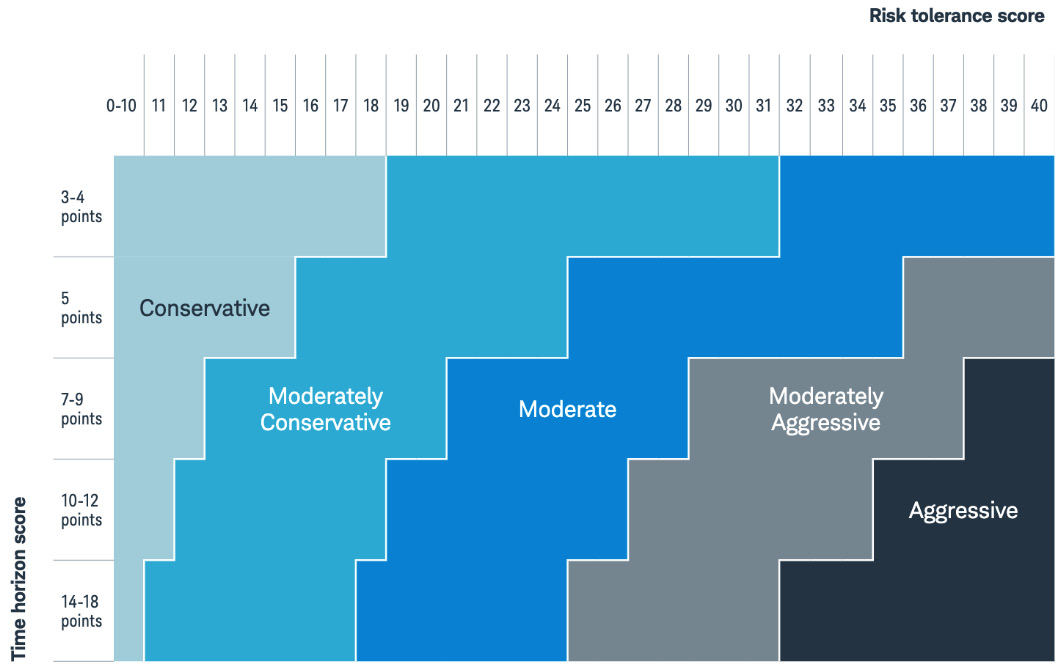

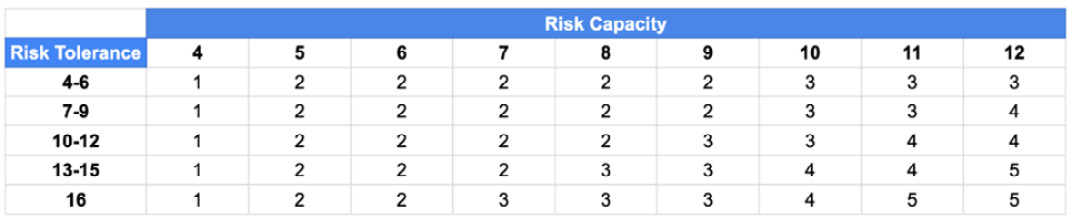

In [16]:
print(riskTolScore)
print(riskCapScore)
myPortfolioID = Portfolio.getPortfolioMapping(riskTolScore, riskCapScore)
print(myPortfolioID)

10
12
4


In [22]:
# if(myPortfolioID == 1):
#   expectedReturn = 0.02
#   portfolioName = "Conservative"
# elif(myPortfolioID == 2):
#   expectedReturn = 0.04
#   portfolioName = "Moderate"
# elif(myPortfolioID == 3):
#   expectedReturn = 0.06
#   portfolioName = "Moderate Growth"
# elif(myPortfolioID == 4):
#   expectedReturn = 0.08
#   portfolioName = "Growth"
# elif(myPortfolioID == 5):
#   expectedReturn = 0.10
#   portfolioName = "Aggressive Growth"

if(myPortfolioID == 1):
  expectedRisk = 0.06
  portfolioName = "Conservative"
elif(myPortfolioID == 2):
  expectedRisk = 0.08
  portfolioName = "Moderate"
elif(myPortfolioID == 3):
  expectedRisk = 0.10
  portfolioName = "Moderate Growth"
elif(myPortfolioID == 4):
  expectedRisk = 0.12
  portfolioName = "Growth"
elif(myPortfolioID == 5):
  expectedRisk = 0.14
  portfolioName = "Aggressive Growth"
  
#VTI: Vanguard Total Stock Market Index Fund ETF
#TLT: iShares 20+ Year Treasury Bond ETF
#IEI: iShares 3-7 Year Treasury Bond ETF
#GLD: SPDR Gold Trust
#DBC: Invesco DB Commodity Index Tracking Fund
#SPY: SPDR S&P 500 ETF Trust


#F123: Al Meezan Mutual Fund
#F122: Meezan Cash Fund
#4AD9: Alfalah GHP Cash Fund
#F061: Alfalah GHP Stock Fund



myPortfolio = Portfolio("F122 4AD9", expectedRisk=expectedRisk, portfolioName = portfolioName, riskBucket = myPortfolioID)
myGoal = Goal(name=investment_goal, targetYear=target_year, targetValue=target_value, portfolio=myPortfolio, initialContribution=initial_contribution, monthlyContribution=monthly_contribution, priority=goal_priority)
myAccount=Account(number="123456789", accountType="Taxable", accountStatus=AccountStatus("APPROVED"), cashBalance=10000.0)
myAccount.goals.append(myGoal)

newOrder = Order(account=myAccount, goal=myGoal, transactionType=TransactionType("BUY"), dollarAmount=10.0)
print(newOrder.checkOrderViability())


KeyError: 'date'

Portfolio Name: Moderate
Risk Bucket: 2
Expected Return: 1.2676148272080185
Expected Risk: 5.417037084557199
Allocations: 
Ticker: AlfalahGHPCashFund, Percentage: 0.0
Ticker: MeezanCashFund, Percentage: 100.0


OptimizationError: ('Please check your objectives/constraints or use a different solver.', 'Solver status: infeasible')

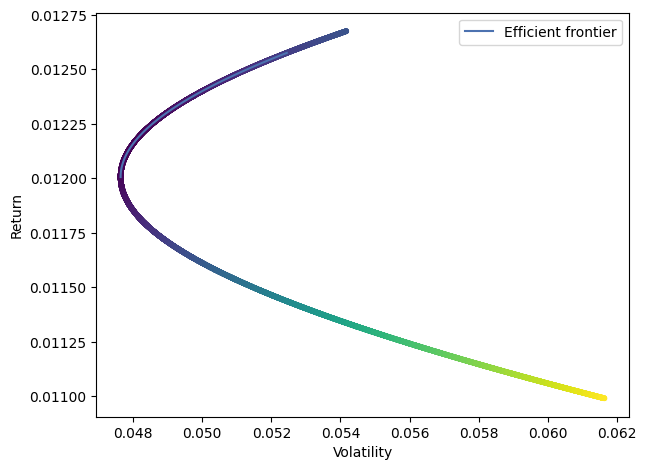

In [ ]:
newOrder.goal.portfolio.printPortfolio()
newOrder.goal.portfolio.showEfficientFrontier()

In [ ]:
for allocation in newOrder.goal.portfolio.allocations:
  print(newOrder.transactionType.value + ": " + allocation.ticker + ", Rs" + str(allocation.percentage * newOrder.dollarAmount))

BUY: AlMeezanMutualFund, Rs3.426
BUY: AlfalahGHPStockFund, Rs6.574
BUY: MeezanCashFund, Rs0.0


In [ ]:
def goalProbabilityForAmount(goalAmount, expectedReturn, portfolioRisk, years, initialInvestment, monthlyInvestment) -> float:
  std = portfolioRisk/math.sqrt(years)
  
  amount = 0
  minReturn = 0.00
  while (amount < goalAmount):
    minReturn = minReturn + 0.0000001
    amount = Projection.returnProjection(minReturn, initialInvestment, monthlyInvestment, years)
  
  z_score = (minReturn-expectedReturn)/std
  return 1-st.norm.cdf(z_score)

In [ ]:
yearsToGoal = myGoal.targetYear - date.today().year
goalProbabilityForAmount(myGoal.targetValue,
                         myPortfolio.expectedReturn,
                         myPortfolio.riskCalculated,
                         yearsToGoal,
                         myGoal.initialContribution,
                         myGoal.monthlyContribution)


20000.0
0.10119666103126632
0.14999999971017058
15
5000.0
496.0
1e-07


0.995510911206161

0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369
0.10119666103126632
0.14999999971017058
0.10119666103126632
-0.04880333867890427
0.2511966607414369


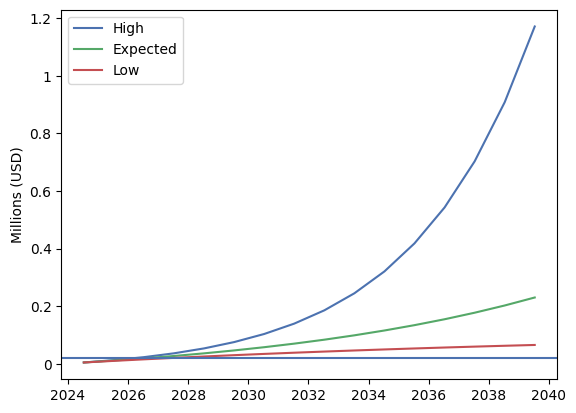

In [ ]:
myProjection = Projection(myPortfolio.expectedReturn,
                          myPortfolio.riskCalculated,
                          myGoal.initialContribution,
                          myGoal.monthlyContribution,
                          yearsToGoal)
myProjection.visualize(myGoal.targetValue)